In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as scop
import csv

from scipy.optimize import curve_fit

#LOADING FUNCTION
def load_magnetisation_data(file_location, 
                            cgs_or_si="cgs", 
                            temp_range=(0, 300)):
    """
    Load, sanitise, and optionally convert magnetisation data 
    from a PPMS datafile (Quantum Design format).

    Parameters
    ----------
    file_location : str
        Directory where the data file is stored.
    cgs_or_si : str, default "cgs"
        Choose "cgs" to keep raw PPMS units or "si" for SI conversion.
    temp_range : tuple, default (0, 300)
        Lower and upper bounds for temperature filtering (K).

    Returns
    -------
    df : pd.DataFrame
        Sanitised dataframe in chosen units and restricted to the temperature range.
    headers_line : int
        Index where headers started in the original file.
    """
    FILEANDPATH = file_location

    # Find where headers start (due to PPMS metadata junk at top of file)
    index_of_headers = 0
    for i in range(100):
        try:
            _ = pd.read_csv(FILEANDPATH, sep=",", skiprows=i, encoding="unicode_escape")
            index_of_headers = i + 1  # need +1 for correct parsing
            break
        except Exception:
            continue

    # Load dataframe properly
    df_raw = pd.read_csv(FILEANDPATH, sep=",", skiprows=index_of_headers, encoding="unicode_escape")

    # Drop columns with all NaNs
    df_clean = df_raw.dropna(axis=1, how="all")

    # Convert to SI if requested
    if cgs_or_si.lower() == "cgs":
        df_final = df_clean.copy()
    elif cgs_or_si.lower() == "si":
        df_final = df_clean.copy()
        df_final["Magnetic Field (Oe)"] *= 0.0001
        df_final["Moment (emu)"] *= 1e-3
        df_final.rename(columns={
            "Magnetic Field (Oe)": "Magnetic Field (T)",
            "Moment (emu)": "Moment (Am^2)"
        }, inplace=True)
    else:
        raise ValueError("cgs_or_si must be either 'cgs' or 'si'")

    # Apply temperature range filter
    lower_temp, higher_temp = temp_range
    df_final = df_final[(df_final["Temperature (K)"] >= lower_temp) & 
                        (df_final["Temperature (K)"] <= higher_temp)]

    print(f"Headers found at line {index_of_headers}")
    #print(f"Remaining Column Headers: {df_final.columns}")

    return df_final, index_of_headers

#SAVE PLOT FUNCTION
import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

def save_next_plot(folder, prefix="graph", ext="png", fig=None):
    """
    Save the current matplotlib figure into 'folder' with auto-increment filename.
    
    Parameters
    ----------
    folder : str
        Path to the folder where plots will be saved.
    prefix : str, default 'graph'
        Filename prefix, e.g. 'graph' -> graph_001.png
    ext : str, default 'png'
        File extension, e.g. 'png', 'pdf', 'svg'.
    fig : matplotlib.figure.Figure, optional
        Figure to save. Defaults to current figure.
        
    Returns
    -------
    str
        Full path of the saved file.
    """
    os.makedirs(folder, exist_ok=True)
    
    existing = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith("." + ext)]
    numbers = []
    for f in existing:
        try:
            num = int(f.replace(prefix + "_", "").replace("." + ext, ""))
            numbers.append(num)
        except ValueError:
            continue
    
    next_num = max(numbers) + 1 if numbers else 1
    filename = f"{prefix}_{next_num:03d}.{ext}"
    fullpath = os.path.join(folder, filename)
    
    if fig is None:
        fig = plt.gcf()
    
    fig.savefig(fullpath, dpi=300, bbox_inches="tight")
    print(f"Plot saved as: {fullpath}")
    
    return fullpath



#examples of loading data
'''
df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="si",
    temp_range=(2, 100)
)
df_mag2, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag2,
    cgs_or_si="si",
    temp_range=(2, 100)
)
'''

'\ndf_mag1, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag1,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\ndf_mag2, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag2,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\n'

Headers found at line 30
Headers found at line 30
Headers found at line 30
0       999.756104
1       999.756104
2       999.756104
3       999.756104
4       999.756104
           ...    
3357    999.756104
3358    999.756104
3359    999.756104
3360    999.756104
3361    999.756104
Name: Magnetic Field (Oe), Length: 3362, dtype: float64


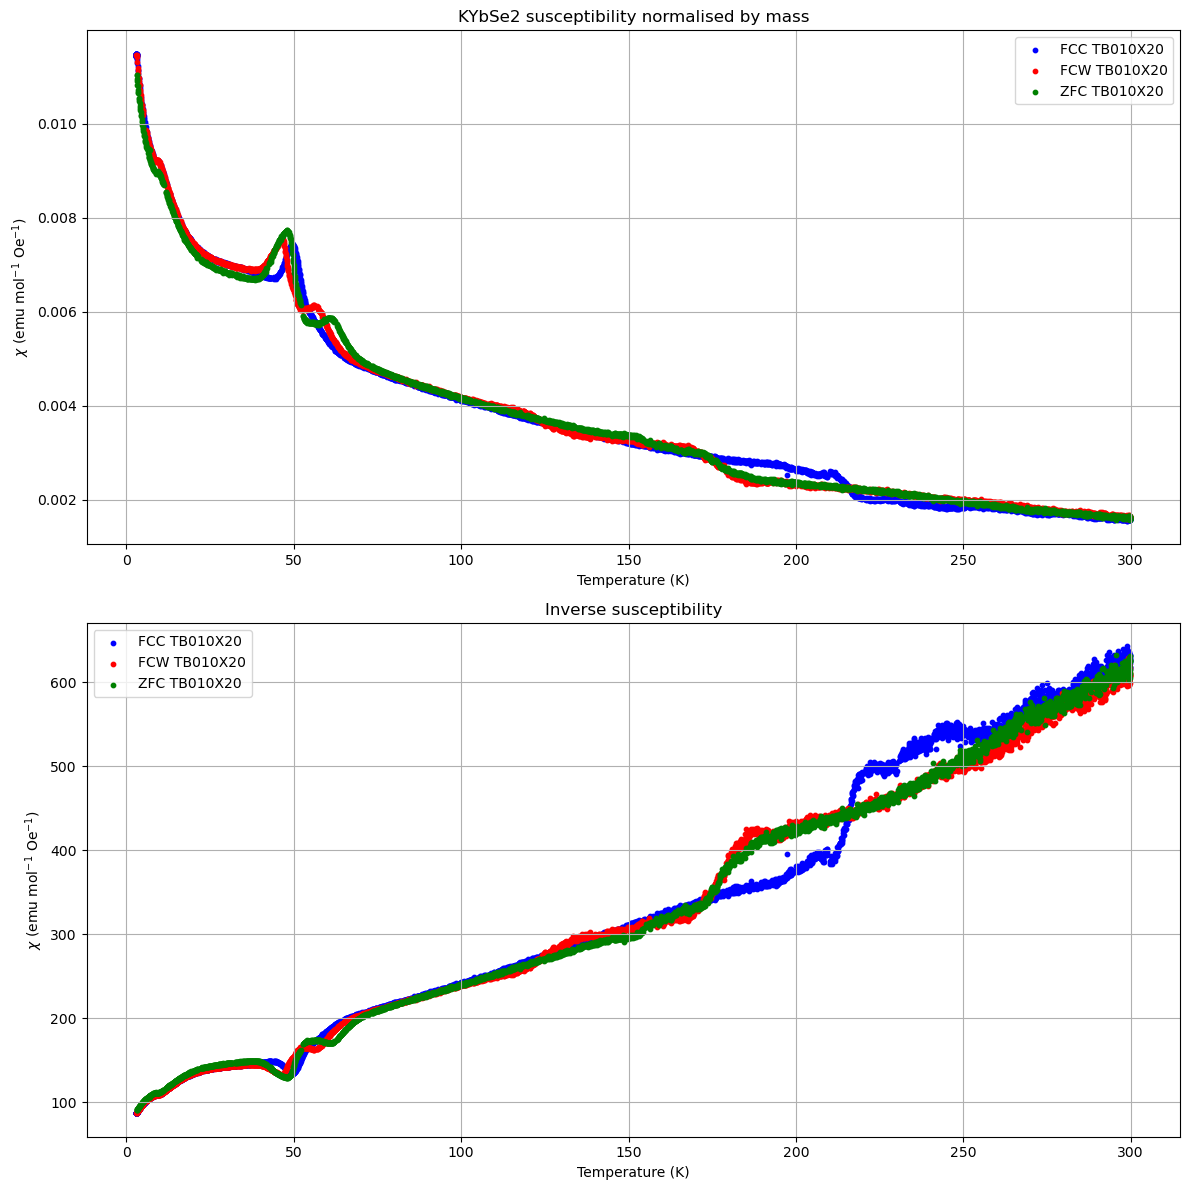

In [57]:
# -----------------------------
# Load your data
# -----------------------------
#Filepath where the point the test datafile exists in so it can be accessed
'''MAGNETISATION DATA'''
filepath = "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/YCOB//"






#file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_5KTO30K.dat"
#file2 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_30K_TO300K.dat"

file1="TB010/YCOB_TB010X20_HPARAAB_070826_FCC_00001.DAT"
file2="TB010/YCOB_TB010X20_HPARAAB_070826_FCW.DAT"
file3="TB010/YCOB_TB010X20_HPARAAB_070826_ZFC.DAT"
file4="TB010/YCOB_TB010X1_HPARAAB_050826_FCC_00001.DAT"
file5="TB010/YCOB_TB010X1_HPARAAB_050826_FCW.DAT"
#file6="TB010/YCOB_TB010X20_HPARAAB_070826_FCC.DAT"
#file7="TB010/YCOB_TB010X20_HPARAAB_070826_FCC.DAT"


FILE1 = filepath + file1
FILE2 = filepath + file2
FILE3 = filepath + file3
FILE4 = filepath + file4
FILE5 = filepath + file5
#FILE6 = filepath + file6
#FILE7 = filepath + file7

# -----------------------------
# Load datasets for stitching together 5 to 30 k and 30 to 300 K
# -----------------------------
df1, header1 = load_magnetisation_data(
    file_location=FILE1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df2, header2 = load_magnetisation_data(
    file_location=FILE2,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df3, header3 = load_magnetisation_data(
    file_location=FILE3,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
"""
df4, header4 = load_magnetisation_data(
    file_location=FILE4,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df5, header5 = load_magnetisation_data(
    file_location=FILE5,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df6, header6 = load_magnetisation_data(
    file_location=FILE6,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df7, header7 = load_magnetisation_data(
    file_location=FILE7,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
"""

# -----------------------------
# Clean + sort (important for physics plots)
# -----------------------------
df1 = df1.replace([np.inf, -np.inf], np.nan)
df1 = df1.dropna(subset=["Temperature (K)", "Moment (emu)"])
df1 = df1.sort_values("Temperature (K)").reset_index(drop=True)

df2 = df2.replace([np.inf, -np.inf], np.nan)
df2 = df2.dropna(subset=["Temperature (K)", "Moment (emu)"])
df2 = df2.sort_values("Temperature (K)").reset_index(drop=True)

df3 = df3.replace([np.inf, -np.inf], np.nan)
df3 = df3.dropna(subset=["Temperature (K)", "Moment (emu)"])
df3 = df3.sort_values("Temperature (K)").reset_index(drop=True)

"""
df4 = df4.replace([np.inf, -np.inf], np.nan)
df4 = df4.dropna(subset=["Temperature (K)", "Moment (emu)"])
df4 = df4.sort_values("Temperature (K)").reset_index(drop=True)

df5 = df5.replace([np.inf, -np.inf], np.nan)
df5 = df5.dropna(subset=["Temperature (K)", "Moment (emu)"])
df5 = df5.sort_values("Temperature (K)").reset_index(drop=True)

df6 = df6.replace([np.inf, -np.inf], np.nan)
df6 = df6.dropna(subset=["Temperature (K)", "Moment (emu)"])
df6 = df6.sort_values("Temperature (K)").reset_index(drop=True)

df7 = df7.replace([np.inf, -np.inf], np.nan)
df7 = df7.dropna(subset=["Temperature (K)", "Moment (emu)"])
df7 = df7.sort_values("Temperature (K)").reset_index(drop=True) 
"""

# -----------------------------
# Extract variables
# -----------------------------
x1 = df1["Temperature (K)"]
M1 = df1["Moment (emu)"]
H1 = df1["Magnetic Field (Oe)"]
print(H1)

x2 = df2["Temperature (K)"]
M2 = df2["Moment (emu)"]
H2 = df2["Magnetic Field (Oe)"]

x3 = df3["Temperature (K)"]
M3 = df3["Moment (emu)"]
H3 = df3["Magnetic Field (Oe)"]

"""
x4 = df4["Temperature (K)"]
M4 = df4["Moment (emu)"]
H4 = df4["Magnetic Field (Oe)"]

x5 = df5["Temperature (K)"]
M5 = df5["Moment (emu)"]
H5 = df5["Magnetic Field (Oe)"]

x6 = df6["Temperature (K)"]
M6 = df6["Moment (emu)"]
H6 = df6["Magnetic Field (Oe)"]

x7 = df7["Temperature (K)"]
M7 = df7["Moment (emu)"]
H7 = df7["Magnetic Field (Oe)"]
"""


"""
df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)"""

# -----------------------------
# Conversion Factor
# -----------------------------
mass1 = 0.0026  # g
mass2 = 0.0026
mass3 = 0.0026
#mass4 = 0.0049
#mass5 = 0.001
#mass6 = 0.0014
#mass7 = 0.0015


molar_mass = 370.0853 # g/mol


chi1 = M1 / H1
y1 = chi1 * molar_mass / mass1
inv_y1 = 1.0 / y1

chi2 = M2 / H2
y2 = chi2 * molar_mass / mass2
inv_y2 = 1.0 / y2

chi3 = M3 / H3
y3 = chi3 * molar_mass / mass3
inv_y3 = 1.0 / y3

"""
chi4 = M4 / H4
y4 = chi4 * molar_mass / mass4
inv_y4 = 1.0 / y4

chi5 = M5 / H5
y5 = chi5 * molar_mass / mass5
inv_y5 = 1.0 / y5

chi6 = M6 / H6
y6 = chi6 * molar_mass / mass6
inv_y6 = 1.0 / y6

chi7 = M7 / H7
y7 = chi7 * molar_mass / mass7
inv_y7 = 1.0 / y7
"""


# -----------------------------
# Define 3-parameter Curie–Weiss
# -----------------------------
def curie_weiss_3param(T, C, theta, chi0):
    return C / (T - theta) + chi0

# -----------------------------
# Fit curie-weiss to the data
# -----------------------------
"""
mask = (x2 > 150) & (x2 < 300)   # fitting window
x_fit = x2[mask]
y_fit = y2[mask]

valid = np.isfinite(x_fit) & np.isfinite(y_fit)
x_fit = x_fit[valid]
y_fit = y_fit[valid]

popt, pcov = curve_fit(curie_weiss_3param, x_fit, y_fit,
                    p0=[0.5, 30, -0.0])  # guesses: C, theta, chi0

C_fit, theta_fit, chi0_fit = popt
perr = np.sqrt(np.diag(pcov))

# assuming C_fit and perr[0] (its 1σ) are from a fit done in emu/mol
# if you used a plotting scale_factor (e.g. 1000), DO NOT apply it here.
C_true = C_fit
dC = perr[0]

mu_eff = 2.828 * np.sqrt(C_true)                 # μB / f.u.
mu_eff_err = 2.828 * 0.5 / np.sqrt(C_true) * dC  # error propagation



print("===== Curie–Weiss Fit =====")
print(f"C      = {C_fit:.4f} ± {perr[0]:.4f} emu K mol^-1 Oe^-1")
print(f"μ_eff  = {mu_eff:.3f} ± {mu_eff_err:.3f} μB")
print(f"θ      = {theta_fit:.2f} ± {perr[1]:.2f} K")
print(f"χ₀     = {chi0_fit:.6f} ± {perr[2]:.6f} emu mol^-1 Oe^-1")

"""

# -----------------------------
# Plot χ(T) with fit
# -----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- χ(T)

ax1.scatter(x1, y1, s=10, color='b', label="FCC TB010X20")
ax1.scatter(x2, y2, s=10, color='r', label="FCW TB010X20")
ax1.scatter(x3, y3, s=10, color='g', label="ZFC TB010X20")
#ax1.scatter(x4, y4, s=10, color='m', label="TB001X4")
#ax1.scatter(x5, y5, s=10, color='c', label="TB001X5")
#ax1.scatter(x6, y6, s=10, color='y', label="TB001X6")
#ax1.scatter(x7, y7, s=10, color='k', label="TB001X7")

"""
T_smooth = np.linspace(min(x_fit), max(x_fit), 500)
ax1.plot(T_smooth, curie_weiss_3param(T_smooth, *popt), 'k--',
        label=f"Curie–Weiss fit\nC={C_fit:.2f}, μ_eff = {mu_eff:.2f}, θ={theta_fit:.1f} K, χ₀={chi0_fit:.4e}")
        """

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax1.set_title("KYbSe2 susceptibility normalised by mass")
#ax1.set_xlim(30, 60)
#ax1.set_ylim(0.015, 0.038)
ax1.grid(True)
ax1.legend()

# --- χ⁻¹(T)
ax2.scatter(x1, inv_y1, s=10, color='b', label="FCC TB010X20")
ax2.scatter(x2, inv_y2, s=10, color='r', label="FCW TB010X20")
ax2.scatter(x3, inv_y3, s=10, color='g', label="ZFC TB010X20")
#ax2.scatter(x4, inv_y4, s=10, color='m', label="TB001X4")
#ax2.scatter(x5, inv_y5, s=10, color='c', label="TB001X5")
#ax2.scatter(x6, inv_y6, s=10, color='y', label="TB001X6")
#ax2.scatter(x7, inv_y7, s=10, color='k', label="TB001X7")

"""
# For comparison, plot inverse of fit
inv_fit = 1.0 / curie_weiss_3param(T_smooth, *popt)
ax2.plot(T_smooth, inv_fit, 'k--', linewidth=2.5)"""

ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax2.set_title("Inverse susceptibility")
#ax2.set_xlim(30, 60)
#ax2.set_ylim(28, 65)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

===== Curie-Weiss Fits =====

FCC TB010X20
C      = 2.7741 ± 0.0945
μ_eff  = 4.710 ± 0.080 μB
θ      = -266.29 ± 7.43 K
χ₀     = -0.003432 ± 0.000107

FCW TB010X20
C      = 1.1822 ± 0.0267
μ_eff  = 3.075 ± 0.035 μB
θ      = -118.19 ± 3.14 K
χ₀     = -0.001238 ± 0.000046

ZFC TB010X20
C      = 1.5726 ± 0.0354
μ_eff  = 3.546 ± 0.040 μB
θ      = -158.97 ± 3.64 K
χ₀     = -0.001884 ± 0.000053


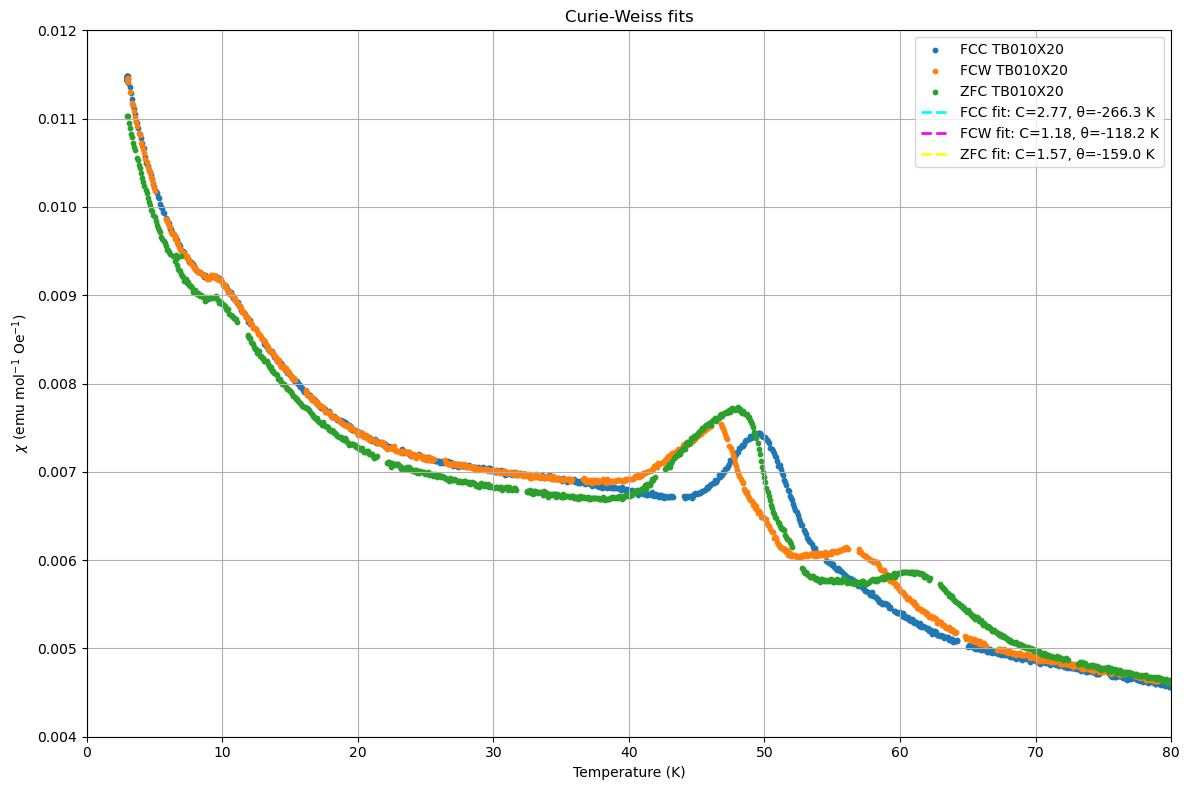

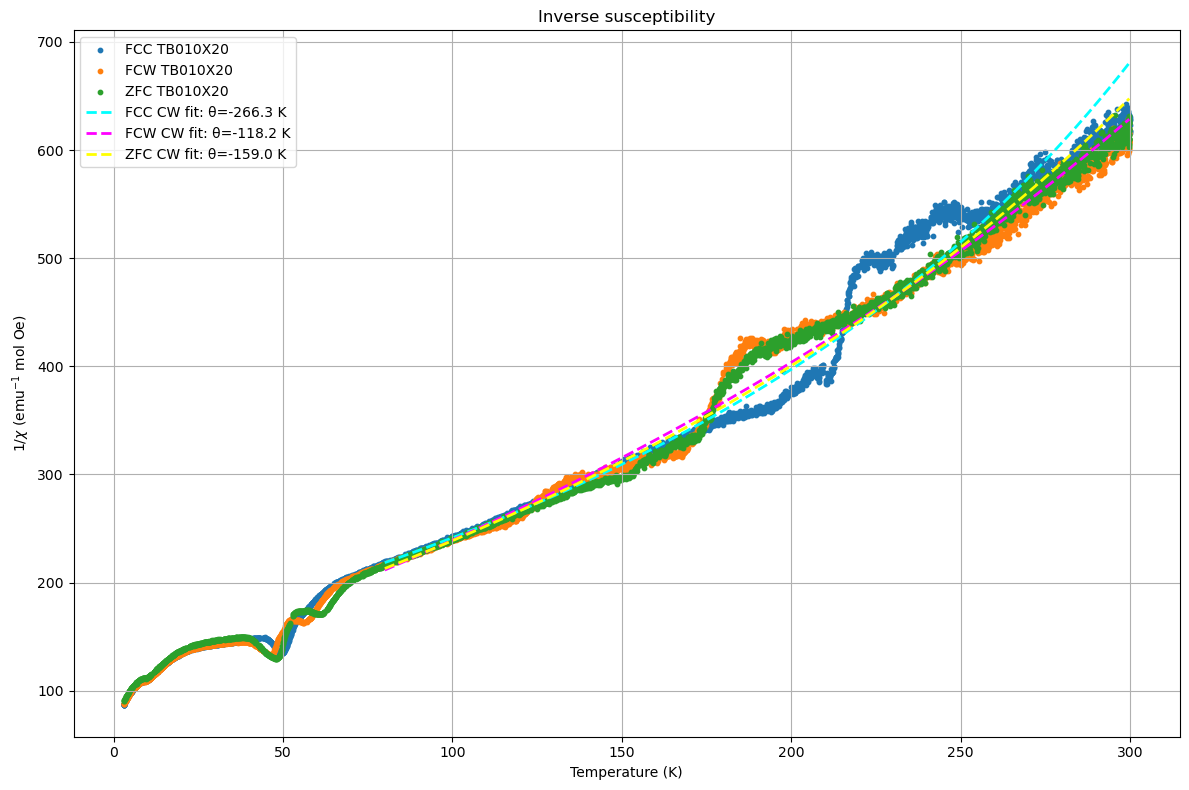

In [58]:
# -----------------------------
# Define 3-parameter Curie-Weiss
# -----------------------------
def curie_weiss_3param(T, C, theta, chi0):
    return C / (T - theta) + chi0


# -----------------------------
# Function to fit one dataset
# -----------------------------
def fit_curie_weiss(x, y, Tmin=80, Tmax=300):
    
    # Select fitting window
    mask = (x > Tmin) & (x < Tmax)
    
    x_fit = x[mask]
    y_fit = y[mask]
    
    # Remove NaN and infinite values
    valid = np.isfinite(x_fit) & np.isfinite(y_fit)
    
    x_fit = x_fit[valid]
    y_fit = y_fit[valid]
    
    # Perform fit
    popt, pcov = curve_fit(
        curie_weiss_3param,
        x_fit,
        y_fit,
        p0=[0.5, 30, 0.0],
        maxfev=1000000
    )
    
    # Parameters
    C, theta, chi0 = popt
    
    # 1-sigma uncertainties
    perr = np.sqrt(np.diag(pcov))
    
    # Effective magnetic moment
    mu_eff = 2.828 * np.sqrt(C)
    mu_eff_err = 2.828 * 0.5 / np.sqrt(C) * perr[0]
    
    return x_fit, y_fit, popt, perr, mu_eff, mu_eff_err


# -----------------------------
# Fit all three datasets
# -----------------------------

x_fit1, y_fit1, popt1, perr1, mu_eff1, mu_eff_err1 = \
    fit_curie_weiss(x1, y1)

x_fit2, y_fit2, popt2, perr2, mu_eff2, mu_eff_err2 = \
    fit_curie_weiss(x2, y2)

x_fit3, y_fit3, popt3, perr3, mu_eff3, mu_eff_err3 = \
    fit_curie_weiss(x3, y3)


# Extract parameters
C1, theta1, chi01 = popt1
C2, theta2, chi02 = popt2
C3, theta3, chi03 = popt3


# -----------------------------
# Print results
# -----------------------------

print("===== Curie-Weiss Fits =====")

print("\nFCC TB010X20")
print(f"C      = {C1:.4f} ± {perr1[0]:.4f}")
print(f"μ_eff  = {mu_eff1:.3f} ± {mu_eff_err1:.3f} μB")
print(f"θ      = {theta1:.2f} ± {perr1[1]:.2f} K")
print(f"χ₀     = {chi01:.6f} ± {perr1[2]:.6f}")

print("\nFCW TB010X20")
print(f"C      = {C2:.4f} ± {perr2[0]:.4f}")
print(f"μ_eff  = {mu_eff2:.3f} ± {mu_eff_err2:.3f} μB")
print(f"θ      = {theta2:.2f} ± {perr2[1]:.2f} K")
print(f"χ₀     = {chi02:.6f} ± {perr2[2]:.6f}")

print("\nZFC TB010X20")
print(f"C      = {C3:.4f} ± {perr3[0]:.4f}")
print(f"μ_eff  = {mu_eff3:.3f} ± {mu_eff_err3:.3f} μB")
print(f"θ      = {theta3:.2f} ± {perr3[1]:.2f} K")
print(f"χ₀     = {chi03:.6f} ± {perr3[2]:.6f}")


# -----------------------------
# Plot all three datasets + fits
# -----------------------------

fig, ax = plt.subplots(figsize=(12, 8))

# Experimental data
ax.scatter(x1, y1, s=10, label="FCC TB010X20")
ax.scatter(x2, y2, s=10, label="FCW TB010X20")
ax.scatter(x3, y3, s=10, label="ZFC TB010X20")


# Smooth temperature ranges for the fits
T_smooth1 = np.linspace(min(x_fit1), max(x_fit1), 500)
T_smooth2 = np.linspace(min(x_fit2), max(x_fit2), 500)
T_smooth3 = np.linspace(min(x_fit3), max(x_fit3), 500)


# Curie-Weiss fits
ax.plot(
    T_smooth1,
    curie_weiss_3param(T_smooth1, *popt1),
    '--', c='cyan',
    linewidth=2,
    label=f"FCC fit: C={C1:.2f}, θ={theta1:.1f} K"
)

ax.plot(
    T_smooth2,
    curie_weiss_3param(T_smooth2, *popt2),
    '--', c='magenta',
    linewidth=2,
    label=f"FCW fit: C={C2:.2f}, θ={theta2:.1f} K"
)

ax.plot(
    T_smooth3,
    curie_weiss_3param(T_smooth3, *popt3),
    '--', c='yellow',
    linewidth=2,
    label=f"ZFC fit: C={C3:.2f}, θ={theta3:.1f} K"
)


ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax.set_title("Curie-Weiss fits")
ax.set_xlim(0, 80)
ax.set_ylim(0.004, 0.012)

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# Plot inverse susceptibility
# -----------------------------

fig, ax = plt.subplots(figsize=(12, 8))

# Calculate inverse susceptibility from experimental data
inv_y1 = 1.0 / y1
inv_y2 = 1.0 / y2
inv_y3 = 1.0 / y3

# Plot experimental inverse susceptibility
ax.scatter(x1, inv_y1, s=10, label="FCC TB010X20")
ax.scatter(x2, inv_y2, s=10, label="FCW TB010X20")
ax.scatter(x3, inv_y3, s=10, label="ZFC TB010X20")


# Smooth temperature ranges
T_smooth1 = np.linspace(min(x_fit1), max(x_fit1), 500)
T_smooth2 = np.linspace(min(x_fit2), max(x_fit2), 500)
T_smooth3 = np.linspace(min(x_fit3), max(x_fit3), 500)


# Inverse of the Curie-Weiss fits
inv_fit1 = 1.0 / curie_weiss_3param(T_smooth1, *popt1)
inv_fit2 = 1.0 / curie_weiss_3param(T_smooth2, *popt2)
inv_fit3 = 1.0 / curie_weiss_3param(T_smooth3, *popt3)


# Plot inverse fits
ax.plot(
    T_smooth1,
    inv_fit1,
    '--',
    color='cyan',
    linewidth=2,
    label=f"FCC CW fit: θ={theta1:.1f} K"
)

ax.plot(
    T_smooth2,
    inv_fit2,
    '--',
    color='magenta',
    linewidth=2,
    label=f"FCW CW fit: θ={theta2:.1f} K"
)

ax.plot(
    T_smooth3,
    inv_fit3,
    '--',
    color='yellow',
    linewidth=2,
    label=f"ZFC CW fit: θ={theta3:.1f} K"
)


ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$1/\chi$ (emu$^{-1}$ mol Oe)")
ax.set_title("Inverse susceptibility")


ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

Headers found at line 30


C:\Users\TXB909\AppData\Local\Temp\ipykernel_39192\3957518730.py:39: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  _ = pd.read_csv(FILEANDPATH, sep=",", skiprows=i, encoding="unicode_escape")


Headers found at line 30


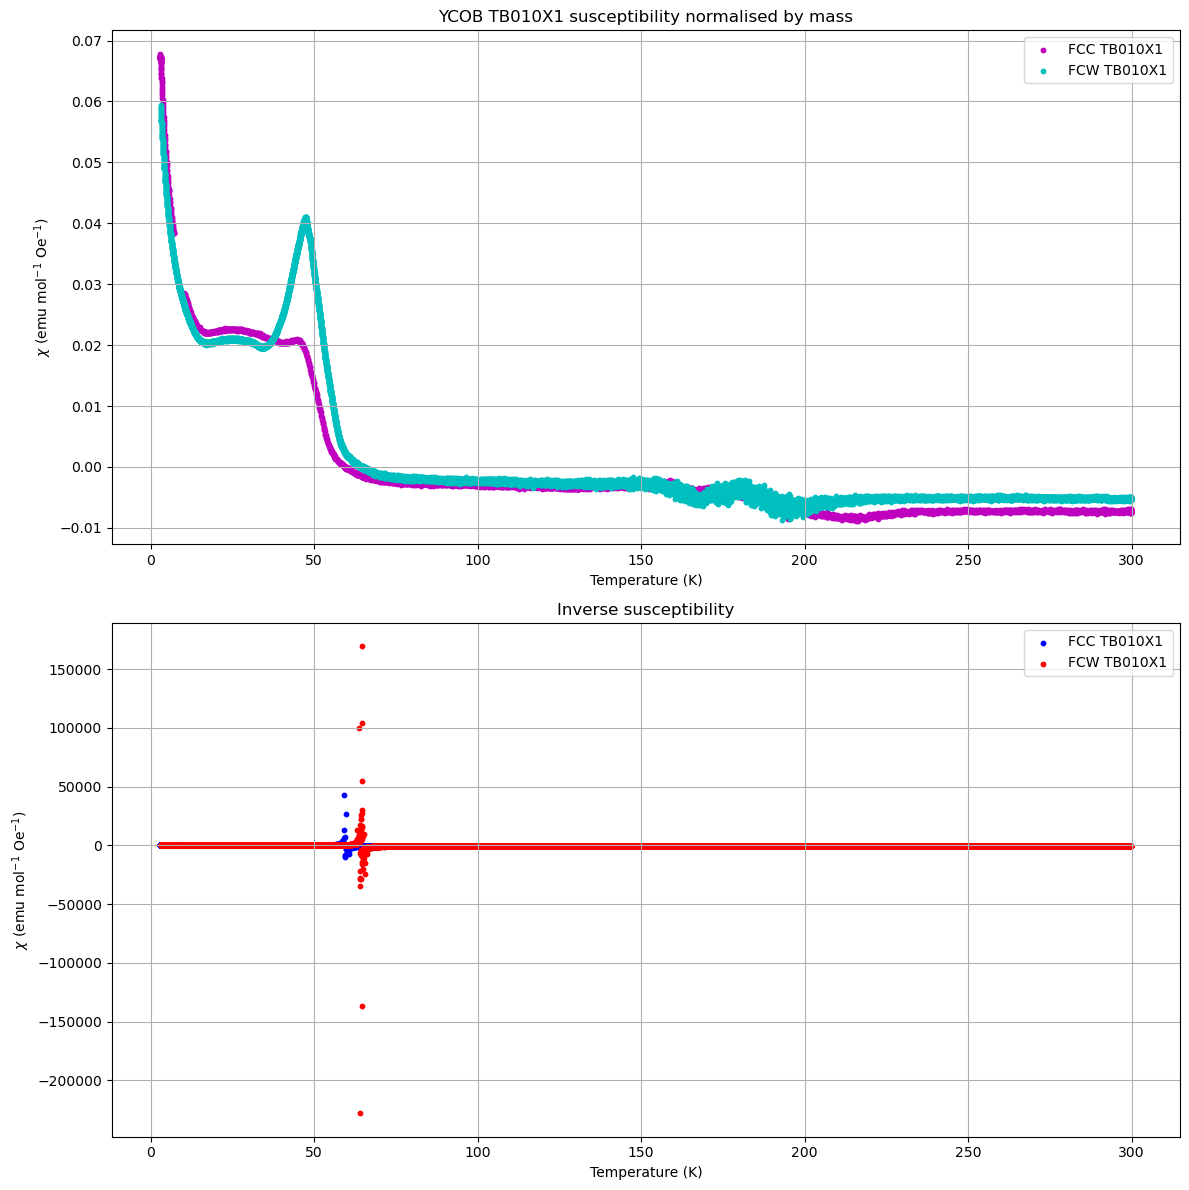

In [60]:
# -----------------------------
# Load your data
# -----------------------------
#Filepath where the point the test datafile exists in so it can be accessed
'''MAGNETISATION DATA'''
filepath = "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/YCOB//"






#file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_5KTO30K.dat"
#file2 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_30K_TO300K.dat"


file4="TB010/YCOB_TB010X1_HPARAAB_050826_FCC_00001.DAT"
file5="TB010/YCOB_TB010X1_HPARAAB_050826_FCW.DAT"
#file6="TB010/YCOB_TB010X20_HPARAAB_070826_FCC.DAT"
#file7="TB010/YCOB_TB010X20_HPARAAB_070826_FCC.DAT"



FILE4 = filepath + file4
FILE5 = filepath + file5
#FILE6 = filepath + file6
#FILE7 = filepath + file7

# -----------------------------
# Load datasets for stitching together 5 to 30 k and 30 to 300 K
# -----------------------------

df4, header4 = load_magnetisation_data(
    file_location=FILE4,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df5, header5 = load_magnetisation_data(
    file_location=FILE5,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
"""
df6, header6 = load_magnetisation_data(
    file_location=FILE6,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
df7, header7 = load_magnetisation_data(
    file_location=FILE7,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)
"""

# -----------------------------
# Clean + sort (important for physics plots)
# -----------------------------

df4 = df4.replace([np.inf, -np.inf], np.nan)
df4 = df4.dropna(subset=["Temperature (K)", "Moment (emu)"])
df4 = df4.sort_values("Temperature (K)").reset_index(drop=True)

df5 = df5.replace([np.inf, -np.inf], np.nan)
df5 = df5.dropna(subset=["Temperature (K)", "Moment (emu)"])
df5 = df5.sort_values("Temperature (K)").reset_index(drop=True)
"""
df6 = df6.replace([np.inf, -np.inf], np.nan)
df6 = df6.dropna(subset=["Temperature (K)", "Moment (emu)"])
df6 = df6.sort_values("Temperature (K)").reset_index(drop=True)

df7 = df7.replace([np.inf, -np.inf], np.nan)
df7 = df7.dropna(subset=["Temperature (K)", "Moment (emu)"])
df7 = df7.sort_values("Temperature (K)").reset_index(drop=True) 
"""

# -----------------------------
# Extract variables
# -----------------------------

x4 = df4["Temperature (K)"]
M4 = df4["Moment (emu)"]
H4 = df4["Magnetic Field (Oe)"]

x5 = df5["Temperature (K)"]
M5 = df5["Moment (emu)"]
H5 = df5["Magnetic Field (Oe)"]
"""
x6 = df6["Temperature (K)"]
M6 = df6["Moment (emu)"]
H6 = df6["Magnetic Field (Oe)"]

x7 = df7["Temperature (K)"]
M7 = df7["Moment (emu)"]
H7 = df7["Magnetic Field (Oe)"]
"""


"""
df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)"""

# -----------------------------
# Conversion Factor
# -----------------------------
#g

mass4 = 0.0001
mass5 = 0.0001
#mass6 = 0.0014
#mass7 = 0.0015


molar_mass = 370.0853 # g/mol



chi4 = M4 / H4
y4 = chi4 * molar_mass / mass4
inv_y4 = 1.0 / y4

chi5 = M5 / H5
y5 = chi5 * molar_mass / mass5
inv_y5 = 1.0 / y5
"""
chi6 = M6 / H6
y6 = chi6 * molar_mass / mass6
inv_y6 = 1.0 / y6

chi7 = M7 / H7
y7 = chi7 * molar_mass / mass7
inv_y7 = 1.0 / y7
"""


# -----------------------------
# Define 3-parameter Curie–Weiss
# -----------------------------
def curie_weiss_3param(T, C, theta, chi0):
    return C / (T - theta) + chi0

# -----------------------------
# Fit curie-weiss to the data
# -----------------------------
"""
mask = (x2 > 150) & (x2 < 300)   # fitting window
x_fit = x2[mask]
y_fit = y2[mask]

valid = np.isfinite(x_fit) & np.isfinite(y_fit)
x_fit = x_fit[valid]
y_fit = y_fit[valid]

popt, pcov = curve_fit(curie_weiss_3param, x_fit, y_fit,
                    p0=[0.5, 30, -0.0])  # guesses: C, theta, chi0

C_fit, theta_fit, chi0_fit = popt
perr = np.sqrt(np.diag(pcov))

# assuming C_fit and perr[0] (its 1σ) are from a fit done in emu/mol
# if you used a plotting scale_factor (e.g. 1000), DO NOT apply it here.
C_true = C_fit
dC = perr[0]

mu_eff = 2.828 * np.sqrt(C_true)                 # μB / f.u.
mu_eff_err = 2.828 * 0.5 / np.sqrt(C_true) * dC  # error propagation



print("===== Curie–Weiss Fit =====")
print(f"C      = {C_fit:.4f} ± {perr[0]:.4f} emu K mol^-1 Oe^-1")
print(f"μ_eff  = {mu_eff:.3f} ± {mu_eff_err:.3f} μB")
print(f"θ      = {theta_fit:.2f} ± {perr[1]:.2f} K")
print(f"χ₀     = {chi0_fit:.6f} ± {perr[2]:.6f} emu mol^-1 Oe^-1")

"""

# -----------------------------
# Plot χ(T) with fit
# -----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- χ(T)


ax1.scatter(x4, y4, s=10, color='m', label="FCC TB010X1")
ax1.scatter(x5, y5, s=10, color='c', label="FCW TB010X1")
#ax1.scatter(x6, y6, s=10, color='y', label="TB001X6")
#ax1.scatter(x7, y7, s=10, color='k', label="TB001X7")

"""
T_smooth = np.linspace(min(x_fit), max(x_fit), 500)
ax1.plot(T_smooth, curie_weiss_3param(T_smooth, *popt), 'k--',
        label=f"Curie–Weiss fit\nC={C_fit:.2f}, μ_eff = {mu_eff:.2f}, θ={theta_fit:.1f} K, χ₀={chi0_fit:.4e}")
        """

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax1.set_title("YCOB TB010X1 susceptibility normalised by mass")
#ax1.set_xlim(30, 60)
#ax1.set_ylim(0.015, 0.038)
ax1.grid(True)
ax1.legend()

# --- χ⁻¹(T)
ax2.scatter(x4, inv_y4, s=10, color='b', label="FCC TB010X1")
ax2.scatter(x5, inv_y5, s=10, color='r', label="FCW TB010X1")
#ax2.scatter(x6, inv_y6, s=10, color='g', label="ZFC TB010X20")
#ax2.scatter(x4, inv_y4, s=10, color='m', label="TB001X4")
#ax2.scatter(x5, inv_y5, s=10, color='c', label="TB001X5")
#ax2.scatter(x6, inv_y6, s=10, color='y', label="TB001X6")
#ax2.scatter(x7, inv_y7, s=10, color='k', label="TB001X7")

"""
# For comparison, plot inverse of fit
inv_fit = 1.0 / curie_weiss_3param(T_smooth, *popt)
ax2.plot(T_smooth, inv_fit, 'k--', linewidth=2.5)"""

ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax2.set_title("Inverse susceptibility")
#ax2.set_xlim(30, 60)
#ax2.set_ylim(28, 65)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()